In [2]:
fig_save_path = "figures/paper_figures"

In [3]:
# from constants import OBJECTIVE_FUNCTIONS_NAMES
from report import final_problems

def load_af_choices(problem, method):
    folder_path = f"numerical_results/{problem}/{method}"
    af_choices = {}
    for i in range(10):
        file_path = f"{folder_path}/{i}_acq_types.txt"
        with open(file_path, 'r') as file:
            # each AF sits in a line
            af_choices[i] = [af for af in file.read().splitlines() if af]
    return af_choices

def load_all_af_choices(method="lmabo"):
    all_af_choices = {}
    for problem in final_problems:
        all_af_choices[problem] = load_af_choices(problem, method)
    return all_af_choices

# AF Frequency

Show the overall selection of AFs by LMABO.

## Overall frequency

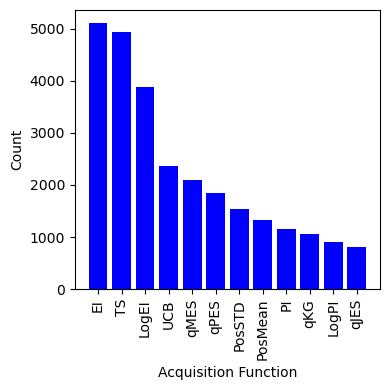

In [42]:
all_af_choices = load_all_af_choices()
# count all AFs
af_count = {}
for problem, problem_choices in all_af_choices.items():
    for i, afs in problem_choices.items():
        for af in afs:
            if af not in af_count:
                af_count[af] = 0
            af_count[af] += 1
# plot the sorted AF count by a bar chart
import matplotlib.pyplot as plt
af_count = dict(sorted(af_count.items(), key=lambda item: item[1], reverse=True))
# make the bars closer to each other
plt.figure(figsize=(4, 4))
plt.bar(af_count.keys(), af_count.values(), width=0.8, color='blue', linewidth=0.7, align='center')
plt.xticks(rotation=90)
plt.xlabel('Acquisition Function')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(f"{fig_save_path}/af_count.pdf", dpi=300, bbox_inches='tight')
plt.show()

## Dataset-specific frequency

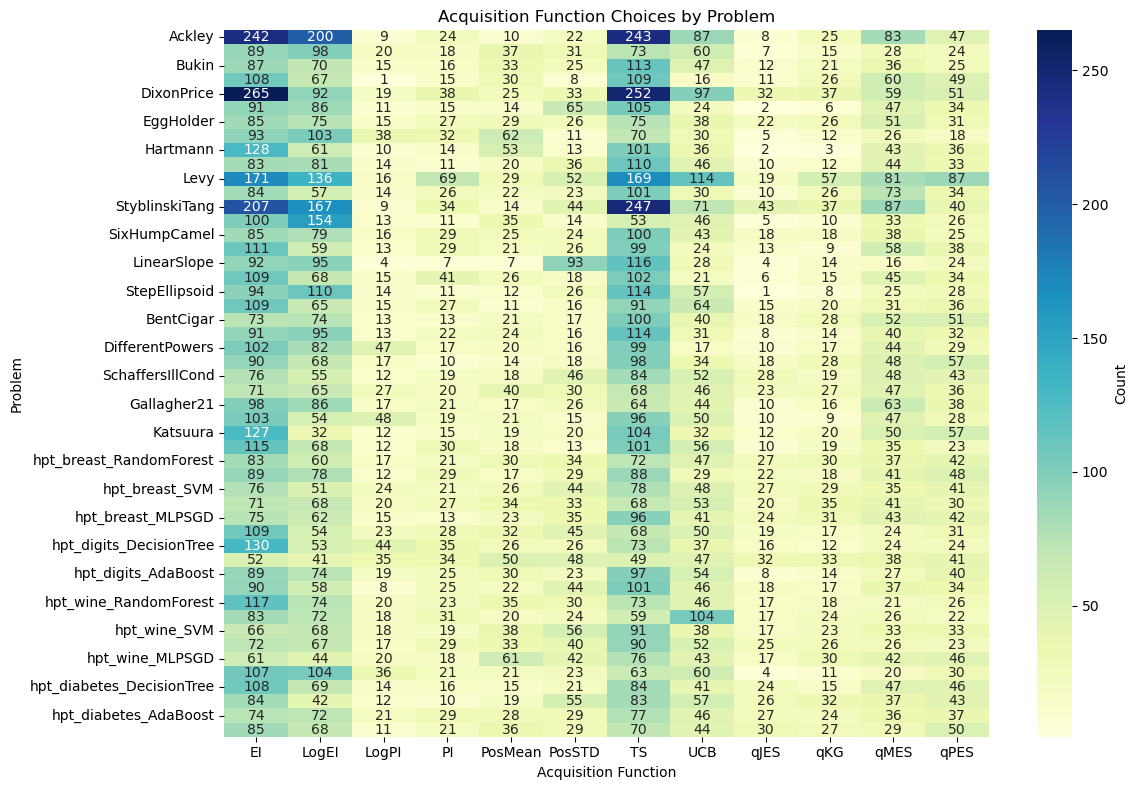

In [43]:
# Plot the AF choices for each problem by a heatmap
# For each problem, count the number of choices for each AF
# The colors should be based on the count of choices on the same problem
# Create a dataframe where rows are problems and columns are AF choices
import seaborn as sns
import numpy as np
import pandas as pd
problems = list(all_af_choices.keys())
af_count_by_problem = {problem: {af: 0 for af in af_count.keys()} for problem in problems}
for problem, choices in all_af_choices.items():
    for i, afs in choices.items():
        for af in afs:
            af_count_by_problem[problem][af] += 1
af_df = pd.DataFrame(af_count_by_problem).T.fillna(0)
af_df = af_df[sorted(af_df.columns)]
plt.figure(figsize=(12, 8))
sns.heatmap(af_df, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': 'Count'})
plt.xlabel('Acquisition Function')
plt.ylabel('Problem')
plt.title('Acquisition Function Choices by Problem')
plt.tight_layout()
plt.show()

# Temporal Analysis

## AF choice by iteration

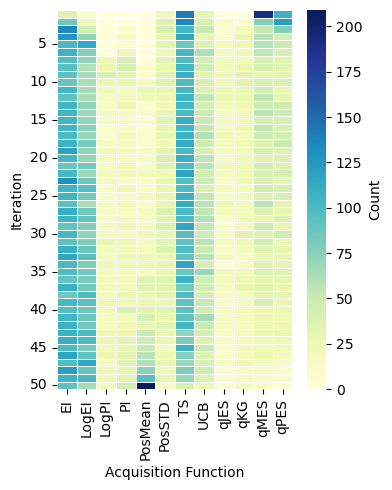

In [44]:
import pandas as pd
import seaborn as sns
import numpy as np
# Count the frequency of each AF per iteration across all problems
# We either have 50 or 100 iterations, depending on the problem, so we will group by 50
# Create a dataframe where rows are iterations and columns are AF choices
# For problems with 100 iterations, we will group them by 50, which means iterations 1 and 2 will be grouped together, 3 and 4, etc.
af_count_by_iteration = {i: {af: 0 for af in af_count.keys()} for i in range(1, 51)}
for problem, choices in all_af_choices.items():
    for afs in choices.values():
        for j, af in enumerate(afs):
            # Group by 50 iterations
            if len(afs) == 50:
                iteration = j + 1
            else:
                # For 100 iterations, we group them by 50
                if j % 2 == 0:  # even index means first of the pair
                    iteration = (j // 2) + 1
            af_count_by_iteration[iteration][af] += 1
af_iter_df = pd.DataFrame(af_count_by_iteration).T.fillna(0)
af_iter_df = af_iter_df[sorted(af_iter_df.columns)]
plt.figure(figsize=(4, 5))
sns.heatmap(af_iter_df, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': 'Count'}, linewidths=0.4)
plt.xlabel('Acquisition Function')
plt.ylabel('Iteration')
plt.yticks(np.arange(4.5, 51.5, 5), np.arange(5, 52, 5))
plt.tight_layout()
plt.savefig(f"{fig_save_path}/af_count_by_iteration.pdf", dpi=300, bbox_inches='tight')
plt.show()

## AF choice with switches

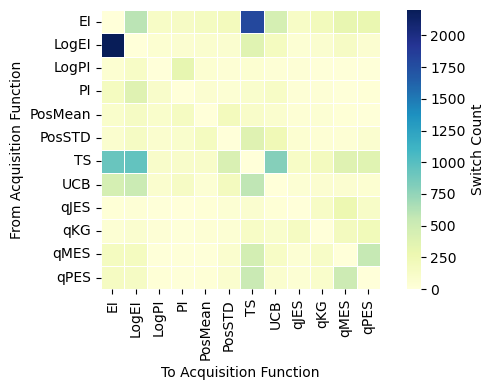

In [45]:
# a heatmap of the number of times the algorithm switched from one AF to another
# For each problem, count the number of switches from one AF to another across all 10 runs
# Organize the same order on both axes
af_switch_count = {af: {af2: 0 for af2 in af_count.keys()} for af in af_count.keys()}
for problem, choices in all_af_choices.items():
    for afs in choices.values():
        for j in range(len(afs) - 1):
            af1 = afs[j]
            af2 = afs[j + 1]
            if af1 != af2:
                af_switch_count[af1][af2] += 1
af_switch_df = pd.DataFrame(af_switch_count).fillna(0)
# Sort both axes by the same order (alphabetical)
af_order = sorted(af_switch_df.columns)
af_switch_df = af_switch_df.loc[af_order, af_order]
plt.figure(figsize=(6, 4))
sns.heatmap(af_switch_df, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': 'Switch Count'}, linewidths=0.4, square=True)
plt.xlabel('To Acquisition Function')
plt.ylabel('From Acquisition Function')
plt.tight_layout()
plt.savefig(f"{fig_save_path}/af_switch_count.pdf", dpi=300, bbox_inches='tight')
plt.show()

# State-conditioned Analysis

## Stagnation vs Improvement

In [46]:
from report import (
    load_results_and_empirical_performance,
    cal_simple_regret,
)
# from constants import OBJECTIVE_FUNCTIONS_NAMES
all_raw_results, empirical_optimum = load_results_and_empirical_performance(
    final_problems, 
    ["lmabo"],
)
all_simple_regret = cal_simple_regret(all_raw_results, empirical_optimum)
# Define stagnation and improvement criteria
threshold = 0
# Convert simple regret to stagnation or improvement
# True (improvement) if the simple regret reduces more than the threshold
# False (stagnation) if the simple regret does not reduce more than the threshold
# Do this for each array where an array of N iterations is converted to a list of N binary labels
all_simple_regret_status = {}
for problem in all_simple_regret.keys():
    all_simple_regret_status[problem] = {}
    for i, simple_regret in enumerate(all_simple_regret[problem]["lmabo"]):
        # Convert to stagnation or improvement
        status = [(simple_regret[j] - simple_regret[j + 1]).item() > threshold for j in range(len(simple_regret) - 1)]
        all_simple_regret_status[problem][i] = status

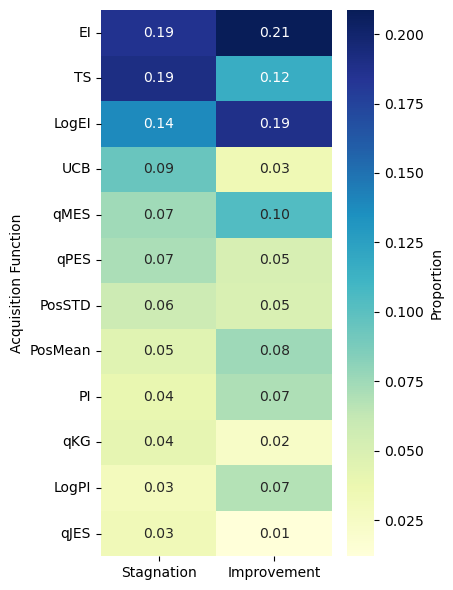

In [47]:
# Now we combine all_simple_regret_status and all_af_choices to count the number of stagnations and improvements for each AF type.
af_combined_status = {af: {"Stagnation": 0, "Improvement": 0} for af in af_count.keys()}
for problem, simple_regret_status_by_problem in all_simple_regret_status.items():
    af_choices_by_problem = all_af_choices[problem]
    for i, status_series in simple_regret_status_by_problem.items():
        af_series = af_choices_by_problem[i]
        for j, status in enumerate(status_series):
                af = af_series[j]
                # Count stagnation and improvement
                if status:
                    af_combined_status[af]["Improvement"] = af_combined_status[af].get("Improvement", 0) + 1
                else:
                    af_combined_status[af]["Stagnation"] = af_combined_status[af].get("Stagnation", 0) + 1

# Create a dataframe for heatmap: rows are AFs, columns are ["Stagnation", "Improvement"], values are proportions across the columns
af_status_df = pd.DataFrame(af_combined_status).T
improvement_total = af_status_df["Improvement"].sum()
stagnation_total = af_status_df["Stagnation"].sum()
af_status_df["Stagnation_prop"] = af_status_df["Stagnation"] / stagnation_total
af_status_df["Improvement_prop"] = af_status_df["Improvement"] / improvement_total
heatmap_df = af_status_df[["Stagnation_prop", "Improvement_prop"]]
heatmap_df = heatmap_df.rename(columns={"Stagnation_prop": "Stagnation", "Improvement_prop": "Improvement"})

plt.figure(figsize=(4.5, 6))
sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label': 'Proportion'})
plt.ylabel("Acquisition Function")
plt.tight_layout()
plt.savefig(f"{fig_save_path}/af_stagnation_improvement_proportion.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Qualitative and Comparative Analysis

## Meta Strategies

We have some meta strategies that we want to compare:
- Explore first with TS then exploit with EI
- Alternating between TS and EI every k iterations (k=1,3,5)

We will need to show the simple regret curves of these results against those of LMABO, EI, and TS.

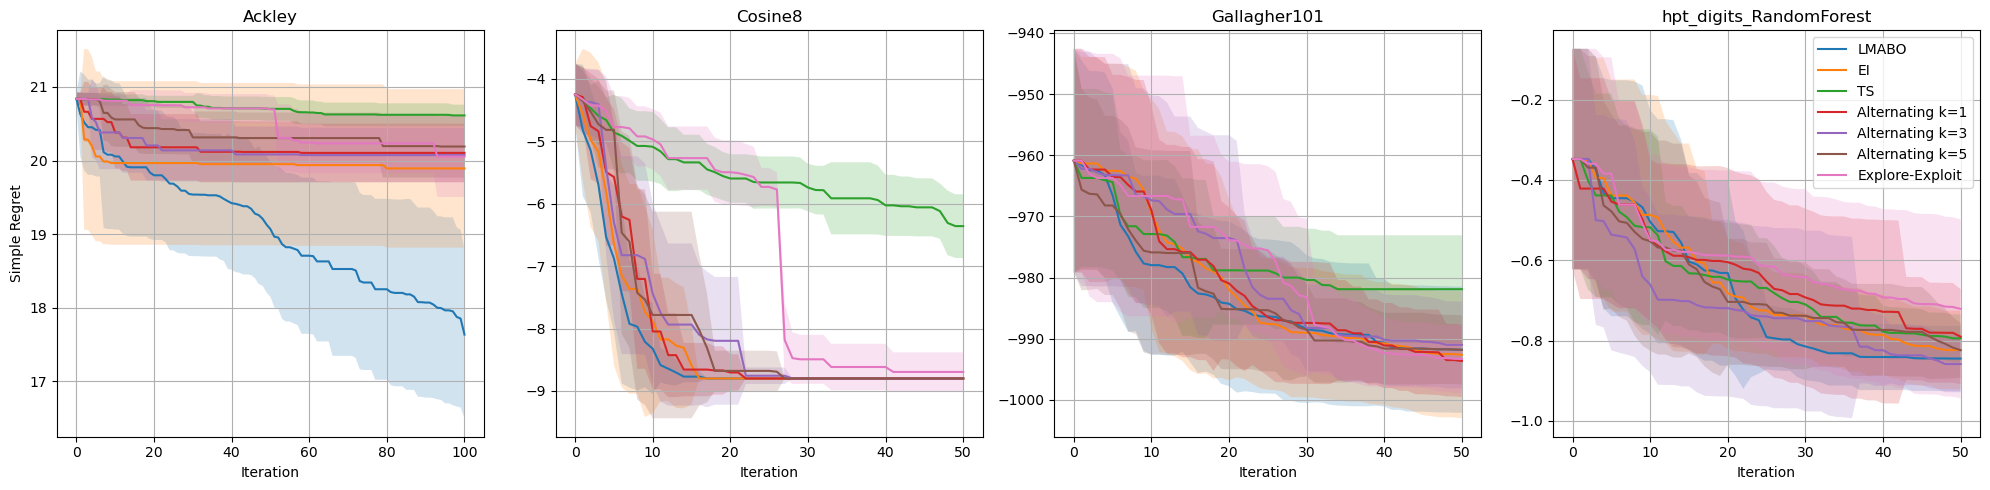

In [ ]:
from report import (
    load_results_and_empirical_performance,
    cal_simple_regret,
)
from constants import ACQ_TYPE_MAPPING, ALGO_FILE_COUNT
# define a subset of problems
problems_subset = ["Ackley", "Cosine8", "Gallagher101", "hpt_digits_RandomForest"]
# define the method set
methods_subset = ["lmabo", "EI", "TS", "bo_alternating_k1", "bo_alternating_k3", "bo_alternating_k5", "bo_explore_exploit"]
method_legend_names = {
    "lmabo": "LMABO",
    "EI": "EI",
    "TS": "TS",
    "bo_alternating_k1": "Alternating k=1",
    "bo_alternating_k3": "Alternating k=3",
    "bo_alternating_k5": "Alternating k=5",
    "bo_explore_exploit": "Explore-Exploit"
}
# load the results for the subset of problems and methods
all_raw_results, empirical_optimum = load_results_and_empirical_performance(
    problems_subset, 
    methods_subset
)
all_best_found = {}
for problem, problem_results in all_raw_results.items():
    all_best_found[problem] = {}
    for algo, algo_results in problem_results.items():
        all_best_found[problem][algo] = []
        for i, series in enumerate(algo_results):
            best_found = np.minimum.accumulate(series)
            # clip the first values
            # we only have either 50 or 100 iterations, depending on the dimensionality
            if problem in ["Cosine8", "Gallagher101", "hpt_digits_RandomForest"]:
                best_found = best_found[-51:]
            else:
                best_found = best_found[-101:]
            all_best_found[problem][algo].append(best_found)
# for each problem, plot them in a single figure
# each method is a line of mean simple regret across 10 runs and a shaded area of min-max across 10 runs
# I want four plots in the same row with separate scale for y-axis
import matplotlib.pyplot as plt
import numpy as np
fig, axes = plt.subplots(1, len(problems_subset), figsize=(20, 5), sharey=False)
for idx, problem in enumerate(problems_subset):
    ax = axes[idx]
    for method, results in all_best_found[problem].items():
        mean_sr = np.mean(results, axis=0)
        # min_sr = np.min(results, axis=0)
        # max_sr = np.max(results, axis=0)
        std_sr = np.std(results, axis=0)
        
        ax.plot(mean_sr, label=method)
        # ax.fill_between(range(len(mean_sr)), min_sr, max_sr, alpha=0.2)
        ax.fill_between(range(len(mean_sr)), mean_sr - std_sr, mean_sr + std_sr, alpha=0.2)
    
    ax.set_title(problem)
    ax.set_xlabel('Iteration')
    if idx == 0:
        ax.set_ylabel('Simple Regret')
    ax.grid(True)
    if idx == len(problems_subset) - 1:
        # legend inside the last plot and use matching color and line for each method
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), [method_legend_names[label] for label in by_label])
plt.tight_layout()
plt.savefig(f"{fig_save_path}/meta_strategies_comparison.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [23]:
from report import get_agg_result
from scipy import stats
subset_auc = {}
for problem in all_best_found.keys():
    # Calculate AUCs for the regret curves for all methods on this problem
    print(f"Problem: {problem}")
    subset_auc[problem] = {}
    for method, results in all_best_found[problem].items():
        subset_auc[problem][method] = [get_agg_result(result, 'auc') for result in results]
    # Perform Friedman test across all methods
    method_aucs = [subset_auc[problem][method] for method in subset_auc[problem].keys()]
    friedman_stat, friedman_p = stats.friedmanchisquare(*method_aucs)
    print(f"Friedman test statistic: {friedman_stat}, p-value: {friedman_p}")
    if friedman_p < 0.05:
        print("Significant differences found among methods. Performing pairwise Wilcoxon post-hoc tests between LMABO and other methods.")
        lmabo_aucs = subset_auc[problem]['lmabo']
        for method in subset_auc[problem].keys():
            if method != 'lmabo':
                other_aucs = subset_auc[problem][method]
                wilcoxon_stat, wilcoxon_p = stats.wilcoxon(lmabo_aucs, other_aucs)
                print(f"Wilcoxon test between LMABO and {method}: statistic={wilcoxon_stat}, p-value={wilcoxon_p}")
                # also print mean AUCs for both methods
                print(f"Mean AUC - LMABO: {np.mean(lmabo_aucs)}, {method}: {np.mean(other_aucs)}")
    else:
        print("No significant differences found among methods.")
    print("="*50)

Problem: Ackley
Friedman test statistic: 34.27191413237925, p-value: 5.960981261800474e-06
Significant differences found among methods. Performing pairwise Wilcoxon post-hoc tests between LMABO and other methods.
Wilcoxon test between LMABO and EI: statistic=10.0, p-value=0.083984375
Mean AUC - LMABO: 1906.6613030849126, EI: 1996.4281302284885
Wilcoxon test between LMABO and TS: statistic=0.0, p-value=0.001953125
Mean AUC - LMABO: 1906.6613030849126, TS: 2070.6993662623204
Wilcoxon test between LMABO and bo_alternating_k1: statistic=3.0, p-value=0.009765625
Mean AUC - LMABO: 1906.6613030849126, bo_alternating_k1: 2017.955284996792
Wilcoxon test between LMABO and bo_alternating_k3: statistic=1.0, p-value=0.00390625
Mean AUC - LMABO: 1906.6613030849126, bo_alternating_k3: 2016.1234053317553
Wilcoxon test between LMABO and bo_alternating_k5: statistic=1.0, p-value=0.00390625
Mean AUC - LMABO: 1906.6613030849126, bo_alternating_k5: 2035.9237993777504
Wilcoxon test between LMABO and bo_expl

# Context

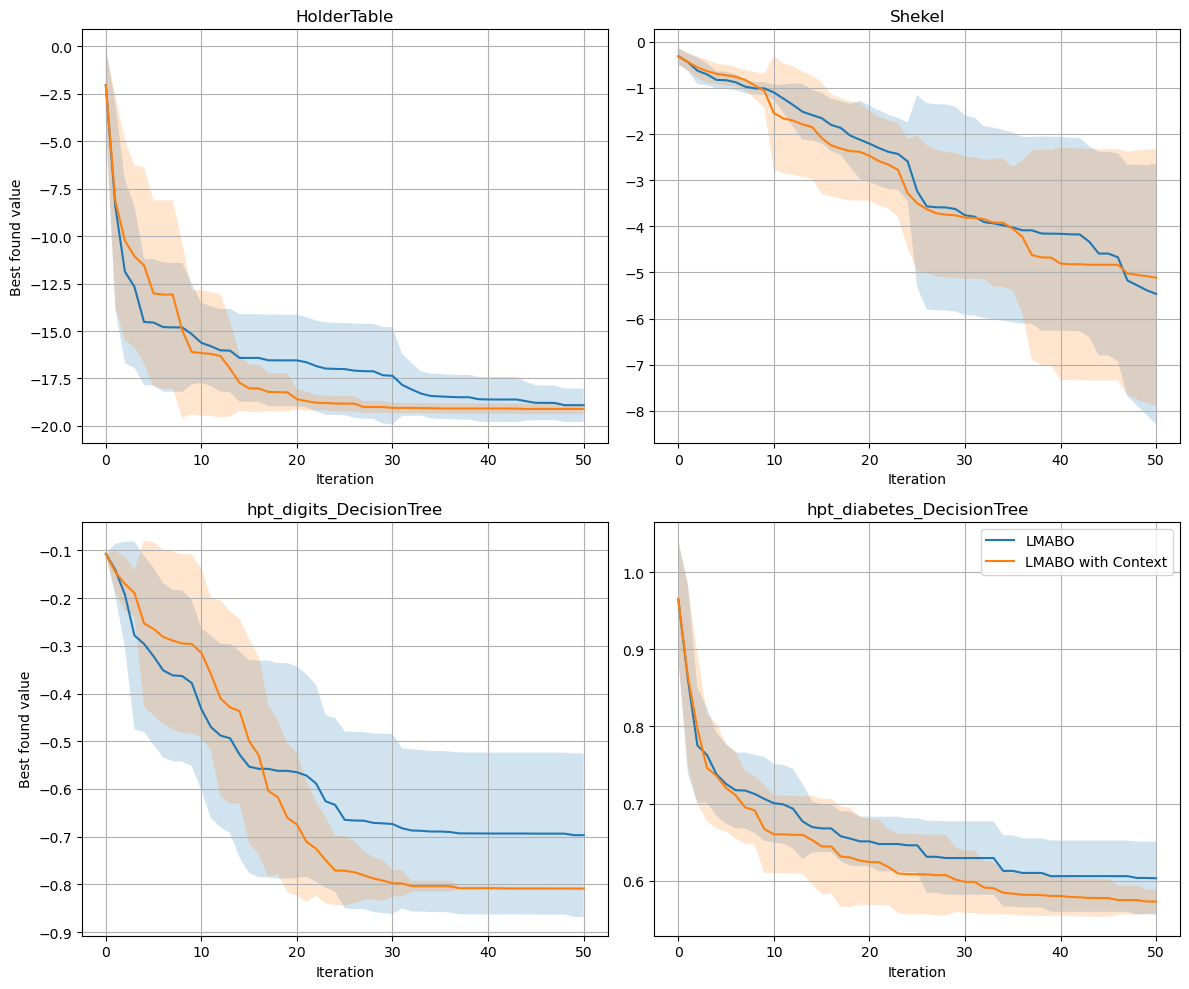

In [3]:
from report import (
    load_results_and_empirical_performance,
)
from constants import ACQ_TYPE_MAPPING, ALGO_FILE_COUNT
import numpy as np
# define a subset of problems
problems_subset = [
    "HolderTable", "Shekel", "hpt_digits_DecisionTree", "hpt_diabetes_DecisionTree"
]
# define the method set
methods_subset = ["lmabo", "lmabo-context"]
method_legend_names = {
    "lmabo": "LMABO",
    "lmabo-context": "LMABO with Context"
}
# load the results for the subset of problems and methods
all_raw_results, empirical_optimum = load_results_and_empirical_performance(
    problems_subset, 
    methods_subset
)
all_best_found = {}
for problem, problem_results in all_raw_results.items():
    all_best_found[problem] = {}
    for algo, algo_results in problem_results.items():
        all_best_found[problem][algo] = []
        for i, series in enumerate(algo_results):
            best_found = np.minimum.accumulate(series[-51:])
            all_best_found[problem][algo].append(best_found)
# for each problem, plot them in a single figure
# each method is a line of mean simple regret across 10 runs and a shaded area of min-max across 10 runs
# I want four plots in the same row with separate scale for y-axis
import matplotlib.pyplot as plt
import numpy as np
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=False)
axes = axes.flatten()
for idx, problem in enumerate(problems_subset):
    ax = axes[idx]
    for method, results in all_best_found[problem].items():
        mean_sr = np.mean(results, axis=0)
        std_sr = np.std(results, axis=0)
        
        ax.plot(mean_sr, label=method)
        ax.fill_between(range(len(mean_sr)), mean_sr - std_sr, mean_sr + std_sr, alpha=0.2)
    
    ax.set_title(problem)
    ax.set_xlabel('Iteration')
    if idx % 2 == 0:
        ax.set_ylabel('Best found value')
    ax.grid(True)
    if idx == len(problems_subset) - 1:
        # legend inside the last plot and use matching color and line for each method
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), [method_legend_names[label] for label in by_label])
plt.tight_layout()
plt.savefig(f"{fig_save_path}/context_comparison_22.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [6]:
from report import get_agg_result
from scipy import stats
subset_auc = {}
for problem in all_best_found.keys():
    # Calculate AUCs for the regret curves for all methods on this problem
    print(f"Problem: {problem}")
    subset_auc[problem] = {}
    for method, results in all_best_found[problem].items():
        subset_auc[problem][method] = [get_agg_result(result, 'auc') for result in results]
    print("LMABO:         ", subset_auc[problem].get('lmabo', []))
    print("LMABO-Context: ", subset_auc[problem].get('lmabo-context', []))
    # Perform Friedman test across all methods
    method_aucs = [subset_auc[problem][method] for method in subset_auc[problem].keys()]
    lmabo_aucs = subset_auc[problem]['lmabo']
    for method in subset_auc[problem].keys():
        if method != 'lmabo':
            other_aucs = subset_auc[problem][method]
            wilcoxon_stat, wilcoxon_p = stats.wilcoxon(other_aucs, lmabo_aucs)
            print(f"Wilcoxon test between LMABO and {method}: statistic={wilcoxon_stat}, p-value={wilcoxon_p}")
            # also print mean AUCs for both methods
            print(f"Mean AUC - LMABO: {np.mean(lmabo_aucs)}, {method}: {np.mean(other_aucs)}")
    print("="*50)

Problem: HolderTable
LMABO:          [-805.9374984927503, -916.1870657535565, -800.3107354559461, -795.8207338180109, -764.4636924763684, -905.5082663664643, -948.6463342394269, -840.3167818933657, -678.0967564330858, -884.8968181684629]
LMABO-Context:  [-862.7599724479186, -934.8279670149158, -855.0613209206194, -810.8848659767893, -760.2344030075488, -865.4762727859013, -888.6013323895145, -876.7200016982805, -869.6301289351861, -936.0435179383552]
Wilcoxon test between LMABO and lmabo-context: statistic=15.0, p-value=0.232421875
Mean AUC - LMABO: -834.0184683097438, lmabo-context: -866.023978311503
Problem: Shekel
LMABO:          [-230.3620801009404, -143.06138389623925, -131.53464320424828, -118.89224046425741, -102.57491240066057, -146.15521491605668, -67.66022483360337, -89.5419380843834, -268.7285739970712, -125.6874931114033]
LMABO-Context:  [-216.44940827408993, -237.54928935759403, -122.40159563070844, -95.15002419367404, -142.27077793006788, -155.9629752082198, -95.131009041

# Final Plots

## Frequency

Acquisition Function Usage Summary Across Different Methods
             LMABO  GP-Hedge  No-PASt-BO   SETUP-BO        ESP
AF                                                            
EI       18.888889  8.092593    6.903704   7.551852   7.459259
LogEI    14.374074  8.244444    7.174074   7.007407   7.581481
PI        4.277778  8.185185    9.392593   9.370370   9.951852
LogPI     3.344444  8.159259    9.481481   8.474074   7.807407
PosMean   4.900000  8.596296   14.025926  10.725926   7.692593
PosSTD    5.677778  7.918519   11.425926   9.711111  10.925926
UCB       8.755556  9.918519    5.425926   8.151852   7.696296
TS       18.248148  7.922222    5.577778   7.325926   8.055556
qKG       3.925926  7.881481    5.966667   7.100000   8.166667
qMES      7.785185  8.174074    6.770370   6.914815   7.703704
qPES      6.825926  9.088889    9.181481  10.792593   8.981481
qJES      2.996296  7.818519    8.674074   6.874074   7.977778


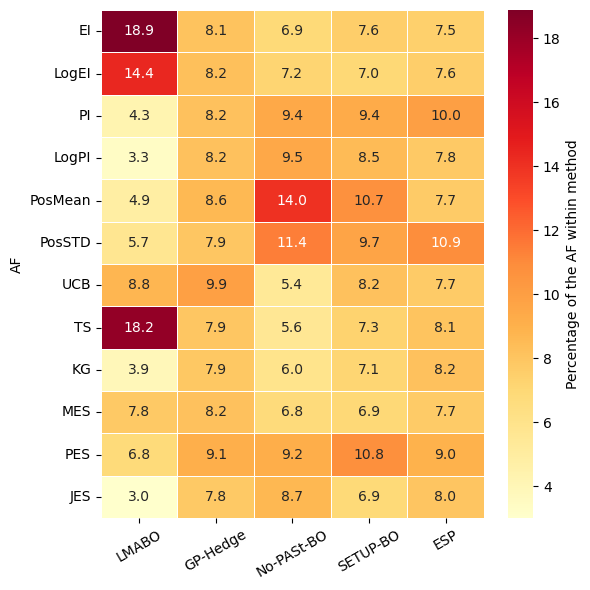

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from constants import ACQ_TYPE_MAPPING
from report import method_name_mapping

# Create a summary table of AF counts for different methods
methods_to_compare = ["lmabo", "gphedge", "no_past_bo", "setup_bo", "esp"]
af_order = [
    "EI", 
    "LogEI", 
    "PI", 
    "LogPI", 
    "PosMean", 
    "PosSTD",
    "UCB", 
    "TS",
    "qKG", 
    "qMES", 
    "qPES", 
    "qJES",
]

# Collect AF counts for all methods
all_method_counts = {}
for method in methods_to_compare:
    method_af_choices = load_all_af_choices(method)
    af_count_method = {}
    for problem, problem_choices in method_af_choices.items():
        for i, afs in problem_choices.items():
            for af in afs:
                if af not in af_count_method:
                    af_count_method[af] = 0
                af_count_method[af] += 1
    all_method_counts[method] = af_count_method

# Get all unique AFs across all methods
all_afs = set()
for method_counts in all_method_counts.values():
    all_afs.update(method_counts.keys())
all_afs = sorted(list(all_afs))

# Create DataFrame
summary_data = []
for af in all_afs:
    row = {'AF': af}
    for method in methods_to_compare:
        row[method_name_mapping[method]] = all_method_counts[method].get(af, 0)
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.set_index('AF')
# convert to percentage within each method
summary_df = summary_df.apply(lambda x: x / x.sum() * 100, axis=0)
# sort the df by af_order
summary_df = summary_df.reindex(af_order)

# Display the table
print("Acquisition Function Usage Summary Across Different Methods")
print("=" * 70)
print(summary_df.to_string())

# Save as CSV for potential further use
summary_df.to_csv(f"{fig_save_path}/af_usage_summary.csv")

# Create a heatmap visualization
plt.figure(figsize=(6, 6))
sns.heatmap(
    summary_df, 
    fmt='.1f', cmap='YlOrRd', 
    cbar_kws={'label': 'Percentage of the AF within method'}, 
    linewidths=0.4,
    annot=True
)
# change y ticks to display names of AF in ACQ_TYPE_MAPPING
plt.yticks(ticks=np.arange(len(ACQ_TYPE_MAPPING.keys())) + 0.5, labels=[ACQ_TYPE_MAPPING[m] for m in summary_df.index])
# set xtick labels to the values of method_name_mapping
plt.xticks(ticks=np.arange(len(methods_to_compare)) + 0.5, labels=[method_name_mapping[m] for m in methods_to_compare], rotation=30)
plt.tight_layout()
plt.savefig(f"{fig_save_path}/af_usage_heatmap.pdf", dpi=300, bbox_inches='tight')
plt.show()

## By iteration

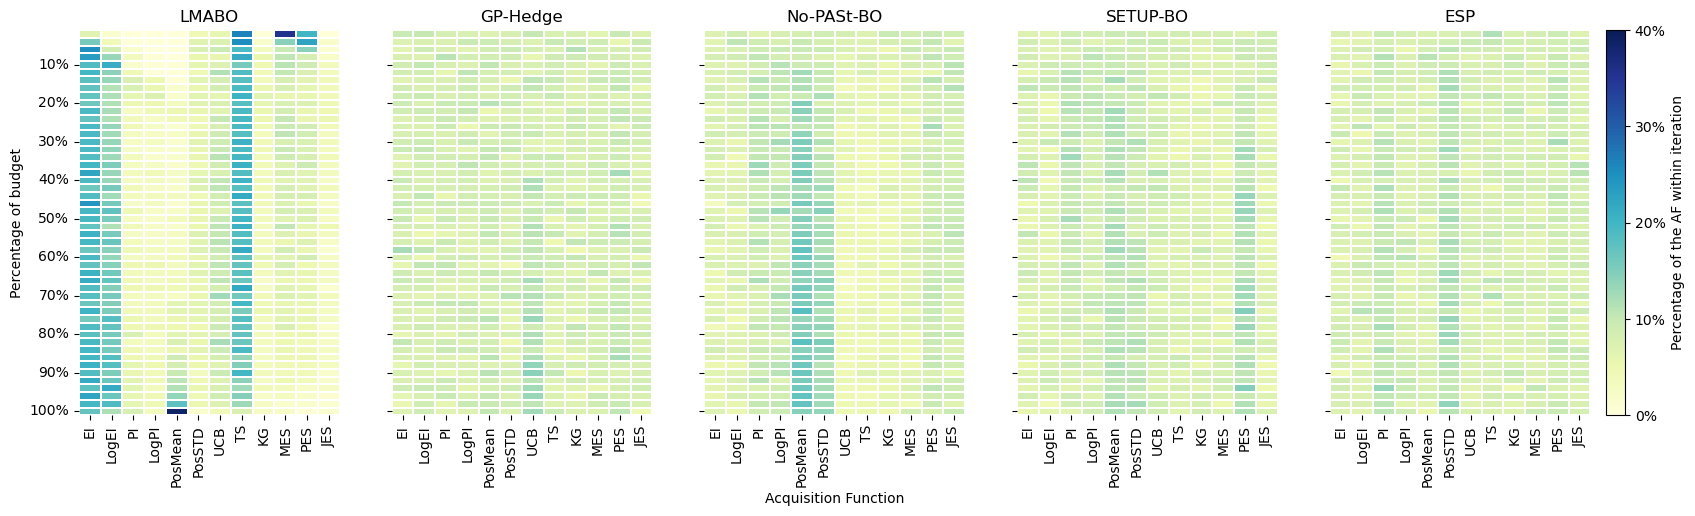

In [4]:
# Modify the plot function to use a consistent colormap range
def plot_af_count_by_iteration_unified(method, ax=None, idx=0, show_title=True, vmin=0, vmax=None):
    all_af_choices = load_all_af_choices(method)
    af_count_by_iteration = {i: {af: 0 for af in ACQ_TYPE_MAPPING.keys()} for i in range(1, 51)}
    for _, choices in all_af_choices.items():
        for afs in choices.values():
            for j, af in enumerate(afs):
                # Group by 50 iterations
                if len(afs) == 50:
                    iteration = j + 1
                else:
                    # For 100 iterations, we group them by 50
                    if j % 2 == 0:  # even index means first of the pair
                        iteration = (j // 2) + 1
                af_count_by_iteration[iteration][af] += 1
    af_iter_df = pd.DataFrame(af_count_by_iteration).T
    af_iter_df = af_iter_df[sorted(af_iter_df.columns)]
    # normalize per iteration and convert to percentage
    af_iter_df = af_iter_df.div(af_iter_df.sum(axis=1), axis=0) * 100
    # sort the df by af_order
    af_iter_df = af_iter_df.reindex(af_order, axis=1)
    
    if ax is None:
        plt.figure(figsize=(4, 5))
        ax = plt.gca()
    
    im = sns.heatmap(af_iter_df, fmt=".0f", cmap="YlGnBu", 
                    #  cbar_kws={'label': 'Percentage of the AF within iteration'} if idx==4 else None,
                     linewidths=0.2, ax=ax, 
                     cbar=False,
                     vmin=vmin, vmax=vmax)
    if idx==2:
        ax.set_xlabel('Acquisition Function')
    if idx==0:
        ax.set_ylabel('Percentage of budget')
    ax.set_yticks(np.arange(4.5, 51.5, 5))
    # set ytick labels to be 10%, 20%, ..., 100%
    ax.set_yticklabels([f"{i}%" for i in range(10, 101, 10)])
    xticklabels = ax.get_xticklabels()
    xticklabels = [method_name_mapping.get(t.get_text(), t.get_text()) for t in xticklabels]
    ax.set_xticklabels(xticklabels, rotation=90)
    if show_title:
        ax.set_title(method_name_mapping.get(method, method))
    
    return ax

# Show the five methods in a single figure with unified colormap
fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=True)
methods_to_plot = ["lmabo", "gphedge", "no_past_bo", "setup_bo", "esp"]

# Use consistent color range across all subplots (0-100% for percentages)
for idx, method in enumerate(methods_to_plot):
    ax = axes[idx]
    plot_af_count_by_iteration_unified(method, ax=ax, idx=idx, show_title=True, vmin=0, vmax=40)

# Add a single colorbar for the entire figure at the right side
cbar = fig.colorbar(axes[0].collections[0], ax=axes, orientation='vertical', fraction=0.015, pad=0.01)
cbar.set_label('Percentage of the AF within iteration')
cbar.set_ticks([0, 10, 20, 30, 40])
cbar.set_ticklabels(['0%', '10%', '20%', '30%', '40%'])
    
plt.savefig(f"{fig_save_path}/af_count_by_iteration_comparison.pdf", dpi=300, bbox_inches='tight')
plt.show()

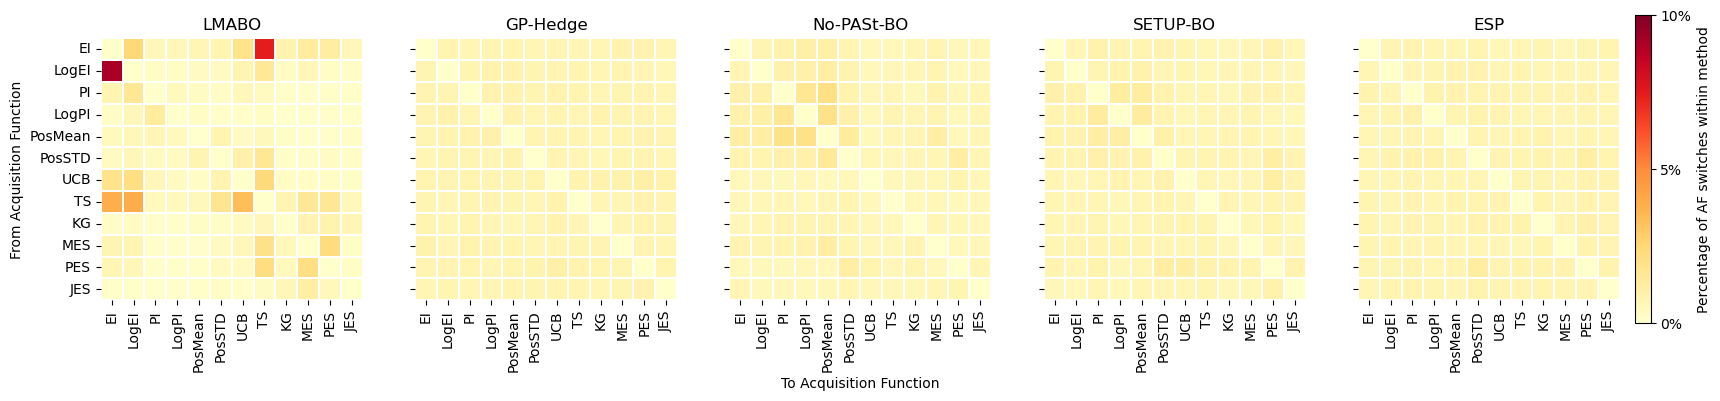

In [4]:
# Create AF switch analysis for all methods
methods_to_compare = ["lmabo", "gphedge", "no_past_bo", "setup_bo", "esp"]

# Collect AF switch counts for all methods
all_method_switches = {}
for method in methods_to_compare:
    method_af_choices = load_all_af_choices(method)
    af_switch_count = {af: {af2: 0 for af2 in af_order} for af in af_order}
    
    for problem, choices in method_af_choices.items():
        for afs in choices.values():
            for j in range(len(afs) - 1):
                af1 = afs[j]
                af2 = afs[j + 1]
                if af1 != af2 and af1 in af_order and af2 in af_order:
                    af_switch_count[af1][af2] += 1
    
    # Convert to DataFrame and normalize by total switches in this method
    af_switch_df = pd.DataFrame(af_switch_count)
    af_switch_df = af_switch_df.loc[af_order, af_order]
    
    # Normalize by total number of switches for this method
    total_switches = af_switch_df.values.sum()
    if total_switches > 0:
        af_switch_df = af_switch_df / total_switches * 100
    
    all_method_switches[method] = af_switch_df

# Create subplot for all methods
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for idx, method in enumerate(methods_to_compare):
    ax = axes[idx]
    af_switch_df = all_method_switches[method]
    
    sns.heatmap(af_switch_df, fmt=".1f", cmap="YlOrRd", 
                linewidths=0.2, ax=ax, 
                cbar=False,
                vmin=0, vmax=10, square=True)
    
    if idx == 2:
        ax.set_xlabel('To Acquisition Function')
    if idx == 0:
        ax.set_ylabel('From Acquisition Function')
    else:
        ax.set_ylabel('')
    
    # Only show y-tick labels for the first plot
    xticklabels = ax.get_xticklabels()
    xticklabels = [ACQ_TYPE_MAPPING.get(t.get_text(), t.get_text()) for t in xticklabels]
    ax.set_xticklabels(xticklabels, rotation=90)
    if idx == 0:
        ax.set_yticklabels(xticklabels, rotation=0)
    else:
        ax.set_yticklabels([])

    ax.set_title(method_name_mapping.get(method, method))
    # set x ticks labels to the values of method_name_mapping

# Add a single colorbar for the entire figure at the right side
# Modify the colorbar to be smaller
cbar = fig.colorbar(axes[0].collections[0], ax=axes, orientation='vertical', fraction=0.01, pad=0.01, shrink=0.8)
cbar.set_label('Percentage of AF switches within method')
cbar.set_ticks([0, 5, 10])
cbar.set_ticklabels(['0%', '5%', '10%'])

plt.savefig(f"{fig_save_path}/af_switch_comparison.pdf", dpi=300, bbox_inches='tight')
plt.show()


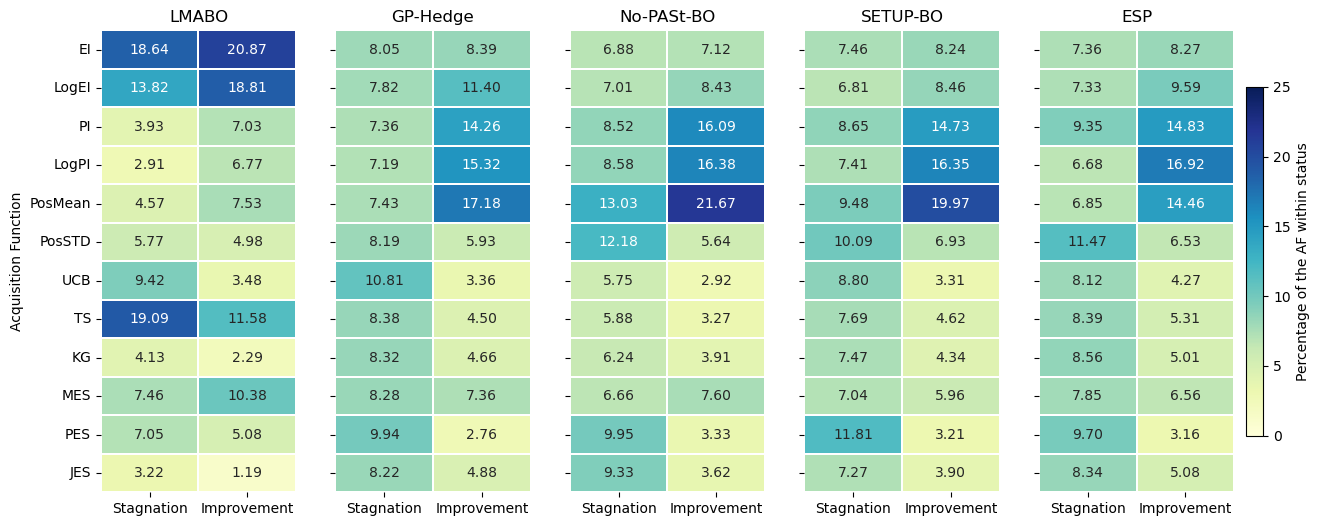

In [10]:
from report import (
    load_results_and_empirical_performance,
    cal_simple_regret,
)
# Create stagnation vs improvement analysis for all methods
methods_to_compare = ["lmabo", "gphedge", "no_past_bo", "setup_bo", "esp"]

# Load results for all methods
all_raw_results_all, empirical_optimum_all = load_results_and_empirical_performance(
    final_problems, 
    methods_to_compare,
)
all_simple_regret_all = cal_simple_regret(all_raw_results_all, empirical_optimum_all)

# Process stagnation/improvement for all methods
all_method_status = {}
threshold = 0

for method in methods_to_compare:
    method_af_choices = load_all_af_choices(method)
    
    # Define stagnation and improvement criteria for this method
    all_simple_regret_status_method = {}
    for problem in all_simple_regret_all.keys():
        all_simple_regret_status_method[problem] = {}
        for i, simple_regret in enumerate(all_simple_regret_all[problem][method]):
            status = [(simple_regret[j] - simple_regret[j + 1]).item() > threshold for j in range(len(simple_regret) - 1)]
            all_simple_regret_status_method[problem][i] = status
    
    # Combine with AF choices
    af_combined_status_method = {af: {"Stagnation": 0, "Improvement": 0} for af in af_order}
    for problem, simple_regret_status_by_problem in all_simple_regret_status_method.items():
        af_choices_by_problem = method_af_choices[problem]
        for i, status_series in simple_regret_status_by_problem.items():
            af_series = af_choices_by_problem[i]
            for j, status in enumerate(status_series):
                af = af_series[j]
                if af in af_order:  # Only consider AFs in our order
                    if status:
                        af_combined_status_method[af]["Improvement"] += 1
                    else:
                        af_combined_status_method[af]["Stagnation"] += 1
    
    # Create proportions
    af_status_df_method = pd.DataFrame(af_combined_status_method).T
    improvement_total = af_status_df_method["Improvement"].sum()
    stagnation_total = af_status_df_method["Stagnation"].sum()
    
    if improvement_total > 0 and stagnation_total > 0:
        af_status_df_method["Stagnation_prop"] = af_status_df_method["Stagnation"]*100 / stagnation_total
        af_status_df_method["Improvement_prop"] = af_status_df_method["Improvement"]*100 / improvement_total
    else:
        af_status_df_method["Stagnation_prop"] = 0
        af_status_df_method["Improvement_prop"] = 0
    
    heatmap_df_method = af_status_df_method[["Stagnation_prop", "Improvement_prop"]]
    heatmap_df_method = heatmap_df_method.rename(columns={"Stagnation_prop": "Stagnation", "Improvement_prop": "Improvement"})
    heatmap_df_method = heatmap_df_method.reindex(af_order)
    
    all_method_status[method] = heatmap_df_method

# Create subplot for all methods
fig, axes = plt.subplots(1, 5, figsize=(15, 6))

for idx, method in enumerate(methods_to_compare):
    ax = axes[idx]
    heatmap_df_method = all_method_status[method]
    
    sns.heatmap(heatmap_df_method, fmt=".2f", cmap="YlGnBu", 
                linewidths=0.15, ax=ax, 
                cbar=False,
                vmin=0, vmax=25,
                annot=True)
    
    if idx == 2:
        ax.set_xlabel('')
    if idx == 0:
        ax.set_ylabel('Acquisition Function')
    else:
        ax.set_ylabel('')
    
    # Only show y-tick labels for the first plot
    if idx != 0:
        ax.set_yticklabels([])
    else:
        # Set y-tick labels using ACQ_TYPE_MAPPING
        yticklabels = [ACQ_TYPE_MAPPING.get(af, af) for af in af_order]
        ax.set_yticklabels(yticklabels)
    
    ax.set_title(method_name_mapping.get(method, method))

# Add a single colorbar for the entire figure at the right side
cbar = fig.colorbar(axes[0].collections[0], ax=axes, orientation='vertical', fraction=0.015, pad=0.01)
cbar.set_label('Percentage of the AF within status')

# plt.tight_layout()
plt.savefig(f"{fig_save_path}/stagnation_improvement_comparison.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Quantifying Justification

In [11]:
# load the messages
from report import final_problems
def load_messages(problem):
    folder_path = f"numerical_results/{problem}/lmabo"
    messages = {}
    for i in range(10):
        file_path = f"{folder_path}/{i}_messages.txt"
        with open(file_path, 'r') as file:
            # each message sits in a line
            messages[i] = [msg for msg in file.read().splitlines() if msg]
        # process messages
        if len(messages[i]) > 100:
            messages[i] = messages[i][1:101]
        else:
            messages[i] = messages[i][1:51]
    return messages

all_messages = {}
for problem in final_problems:
    all_messages[problem] = load_messages(problem)

# print total number of messages loaded
total_messages = sum(len(msgs) for problem_msgs in all_messages.values() for msgs in problem_msgs.values())
print(f"Total messages loaded: {total_messages}")

# aggregate the messages by AF
# remember that each message is in the form "<AF_NAME>: <JUSTIFICATION>", but some are invalid
# for each AF, we create a dictionary keeping the frequency of each word in the justifications
from constants import ACQ_TYPE_MAPPING # this contains the valid AF names
from collections import defaultdict
import re
af_word_counts = {af: defaultdict(int) for af in ACQ_TYPE_MAPPING.keys()}
# also keep a dictionary of AF and their corresponding justifications
af_justifications = {af: [] for af in ACQ_TYPE_MAPPING.keys()}
for problem, problem_messages in all_messages.items():
    for run_messages in problem_messages.values():
        for msg in run_messages:
            # extract the AF name and justification using regex
            match = re.match(r"([A-Za-z0-9]+): (.+)", msg)
            if match:
                af_name = match.group(1)
                justification = match.group(2)
                if af_name in af_word_counts:
                    af_justifications[af_name].append(justification)
                    # split the justification into words, remove punctuation, and convert to lowercase
                    words = re.findall(r'\b\w+\b', justification.lower())
                    for word in words:
                        af_word_counts[af_name][word] += 1
# for each AF, print the top 40 words
# create a list of commont words to ignore
common_words = set(['the', 'and', 'to', 'of', 'a', 'in', 'is', 'that', 'it', 'for', 'on', 'as', 'with', 'this', 'are', 'an', 'be', 'by', 'at', 'from', 'or', 'not', 'but', 'we', 'all', 'can', 'if', 'so', 'more', 'there', 'what', 'when', 'which'])
# remove common words from the counts
# save the union of common words for all AFs
portfolio_common_words = set()
for af, word_count in af_word_counts.items():
    for common_word in common_words:
        if common_word in word_count:
            del word_count[common_word]
    # get the top 40 words
    top_words = sorted(word_count.items(), key=lambda x: x[1], reverse=True)[:40]
    top_words_set = set(word for word, count in top_words)
    if not portfolio_common_words:
        portfolio_common_words = top_words_set
    else:
        portfolio_common_words = portfolio_common_words.union(top_words_set)
    print(f"Top words for {af} ({ACQ_TYPE_MAPPING.get(af, af)}):")
    for word, count in top_words:
        print(f"  {word}: {count}")
    print("\n")
print(f"Common words across all AFs: {portfolio_common_words}")

Total messages loaded: 27850
Top words for PI (PI):
  improvement: 2570
  f_min: 1776
  pi: 1543
  probability: 1461
  model: 1167
  iterations: 1067
  current: 992
  small: 885
  exploitation: 876
  very: 850
  direct: 822
  lengthscales: 786
  any: 747
  s: 715
  best: 679
  still: 655
  better: 652
  has: 621
  ei: 619
  finding: 609
  than: 595
  improve: 591
  have: 575
  high: 568
  local: 562
  failed: 560
  function: 559
  indicating: 559
  aggressive: 535
  distance: 526
  shortest: 512
  logei: 511
  given: 503
  remaining: 493
  stagnation: 485
  remains: 481
  point: 469
  only: 456
  choice: 453
  while: 447


Top words for LogPI (LogPI):
  improvement: 1880
  f_min: 1222
  small: 1119
  logpi: 1102
  very: 859
  pi: 855
  improvements: 743
  iterations: 702
  model: 679
  probability: 654
  lengthscales: 537
  still: 514
  has: 483
  any: 459
  distance: 454
  s: 447
  exploitation: 445
  shortest: 441
  indicating: 438
  failed: 434
  function: 433
  improve: 423
  choic

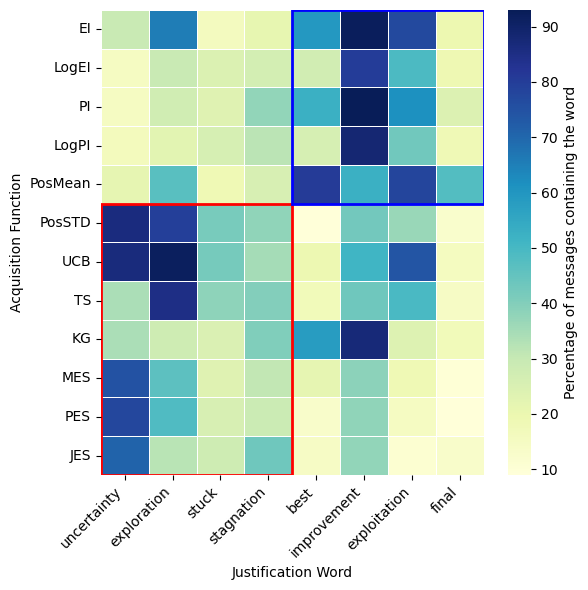

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
explorative_word_portfolio = set(
    ["exploration", "uncertainty", "stagnation", "stuck"]
)
exploitative_word_portfolio = set(
    ["best", "exploitation", "improvement", "final"]
)
af_order = [
    "EI", 
    "LogEI", 
    "PI", 
    "LogPI", 
    "PosMean", 
    "PosSTD",
    "UCB", 
    "TS",
    "qKG", 
    "qMES", 
    "qPES", 
    "qJES",
]
# unionize two portfolios into a list
final_portfolio = list(explorative_word_portfolio)
final_portfolio.extend(list(exploitative_word_portfolio))
# for each AF, among its messages, count the number of times each word in the final_portfolio appears, do not double count within a message
af_final_word_counts = {af: {word: 0 for word in final_portfolio} for af in ACQ_TYPE_MAPPING.keys()}
for af, justifications in af_justifications.items():
    for justification in justifications:
        words_in_msg = set(re.findall(r'\b\w+\b', justification.lower()))
        for word in final_portfolio:
            if word in words_in_msg:
                af_final_word_counts[af][word] += 1
# convert to dataframe
af_final_word_df = pd.DataFrame(af_final_word_counts).T.astype(float)
# normalize by the total number of messages for each AF
af_message_counts = {af: len(justifications) for af, justifications in af_justifications.items()}
for af in af_final_word_df.index:
    if af in af_message_counts and af_message_counts[af] > 0:
        af_final_word_df.loc[af] = af_final_word_df.loc[af] / af_message_counts[af] * 100
# sort the df by af_order
af_final_word_df = af_final_word_df.reindex(af_order)
# sort the columns by the order in final_portfolio
af_final_word_df = af_final_word_df[final_portfolio]
# plot the heatmap  with annotations
plt.figure(figsize=(6, 6))
sns.heatmap(af_final_word_df, fmt=".1f", cmap="YlGnBu", 
            cbar_kws={'label': 'Percentage of messages containing the word'}, 
            linewidths=0.4, annot=False)
# draw two boxes on the heatmap to highlight cells
# first box is at the bottom left 7x4
plt.gca().add_patch(plt.Rectangle((0, 5), 4, 7, fill=False, edgecolor='red', lw=2))
plt.gca().add_patch(plt.Rectangle((4, 0), 4, 5, fill=False, edgecolor='blue', lw=2))
plt.ylabel("Acquisition Function")
plt.xlabel("Justification Word")
plt.xticks(rotation=45, ha='right')
# Set y-tick labels using ACQ_TYPE_MAPPING
yticklabels = [ACQ_TYPE_MAPPING.get(af, af) for af in af_order]
plt.gca().set_yticklabels(yticklabels)
plt.tight_layout()
plt.savefig(f"{fig_save_path}/af_justification_word_heatmap.pdf", dpi=300, bbox_inches='tight')
plt.show()